# Semana 8



## Datos de imágenes

Carga y preprocesamiento del dataset CIFAR-10 (10 clases de objetos a color), imágenes a color (32x32).



In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, applications

# Configuración de semillas para reproducibilidad
tf.random.set_seed(42); np.random.seed(42)

# Carga de datos CIFAR-10 (Imágenes a color de 10 categorías)
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Preprocesamiento: Normalización (rango 0 a 1)
train_images, test_images = train_images / 255.0, test_images / 255.0

print(f"Forma de entrenamiento: {train_images.shape}")
print(f"Forma de prueba: {test_images.shape}")


Forma de entrenamiento: (50000, 32, 32, 3)
Forma de prueba: (10000, 32, 32, 3)


## Modelo CNN

 Definimos una CNN desde cero para entender el flujo básico.

In [6]:
# Definición de arquitectura CNN + Aproximación a Transfer Learning
model_base = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # Capas Convolucionales (Extracción de patrones)
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'), # Conserva tamaño
    layers.MaxPooling2D((2, 2)), # Reduce a la mitad

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Clasificación
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_base.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model_base.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,250 (1.08 MB)

 Trainable params: 282,250 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

## Aproximación a Transfer Learning

Usamos MobileNetV2 para comparar cómo mejora el rendimiento con un modelo preentrenado (capa base).

In [7]:

# Implementar Transfer Learning con Dropout para regularización
base_mobile = applications.MobileNetV2(input_shape=(96, 96, 3),
                                       include_top=False,
                                       weights='imagenet')
base_mobile.trainable = False

model_tl = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.UpSampling2D((3, 3)),
    base_mobile,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3), # Apaga el 30% de neuronas aleatoriamente para evitar sobreajuste
    layers.Dense(10, activation='softmax')
])

model_tl.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

print("Modelo Transfer Learning con Dropout listo.")


Modelo Transfer Learning con Dropout listo.


## Entrenamiento/evaluación

 Evidenciar métricas. Aquí generamos las métricas y los gráficos

Entrenando Modelo Base (6 épocas)...
Epoch 1/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 60ms/step - accuracy: 0.4508 - loss: 1.5283 - val_accuracy: 0.5703 - val_loss: 1.2403
Epoch 2/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.5981 - loss: 1.1440 - val_accuracy: 0.6206 - val_loss: 1.1046
Epoch 3/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step - accuracy: 0.6509 - loss: 1.0066 - val_accuracy: 0.6493 - val_loss: 1.0203
Epoch 4/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.6807 - loss: 0.9213 - val_accuracy: 0.6585 - val_loss: 0.9896
Epoch 5/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.7050 - loss: 0.8523 - val_accuracy: 0.6630 - val_loss: 0.9757
Epoch 6/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 59ms/step - accuracy: 0.7286 - loss: 0.7921 - val_accuracy: 0.6640 - val_loss: 0.9765

Entrenando Modelo Transfer Learning (6 épocas)...
Epoch 1/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 185s 292ms/step - accuracy: 0.6571 - loss: 1.0077 - val_accuracy: 0.7591 - val_loss: 0.7058
Epoch 2

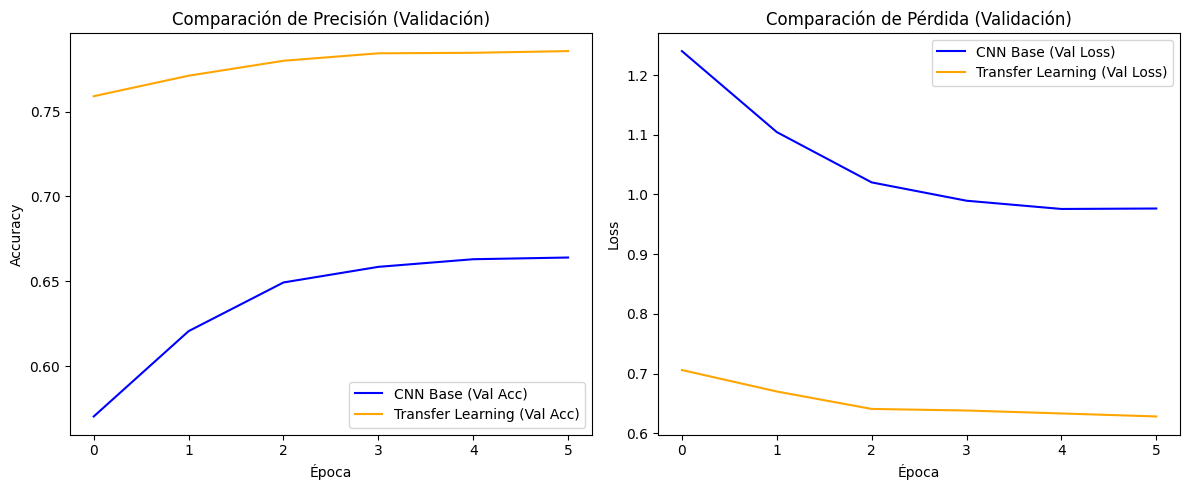

In [8]:
# Entrenamiento de ambos modelos
print("Entrenando Modelo Base (6 épocas)...")
h_base = model_base.fit(train_images, train_labels, epochs=6, validation_split=0.2, batch_size=64, verbose=1)

print("\nEntrenando Modelo Transfer Learning (6 épocas)...")
h_tl = model_tl.fit(train_images, train_labels, epochs=6, validation_split=0.2, batch_size=64, verbose=1)

# Visualización de resultados comparativos
plt.figure(figsize=(12, 5))

# Comparación de Precisión
plt.subplot(1, 2, 1)
plt.plot(h_base.history['val_accuracy'], label='CNN Base (Val Acc)', color='blue')
plt.plot(h_tl.history['val_accuracy'], label='Transfer Learning (Val Acc)', color='orange')
plt.title('Comparación de Precisión (Validación)')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

# Comparación de Pérdida
plt.subplot(1, 2, 2)
plt.plot(h_base.history['val_loss'], label='CNN Base (Val Loss)', color='blue')
plt.plot(h_tl.history['val_loss'], label='Transfer Learning (Val Loss)', color='orange')
plt.title('Comparación de Pérdida (Validación)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()




## Conclusiones

**TODO:** Explicar conv/padding/stride y hallazgos.

- Convolución (Conv): Es el proceso donde los filtros recorren la imagen detectando rasgos como bordes y texturas. Al incrementar de 32 a 64 filtros, la red logra combinar rasgos simples para entender conceptos visuales más complejos.

- Padding ('same'): Técnica que añade bordes para mantener el tamaño original de la imagen (32x32). Esto es crucial para no perder información en los bordes y esquinas de la imagen.

- Stride (Zancada): Se mantuvo en 1. Un salto pequeño garantiza un análisis exhaustivo de cada píxel, algo vital en imágenes pequeñas de 32x32 como las de CIFAR-10.

- Hallazgo de Transfer Learning: La comparación evidencia que usar un modelo preentrenado (MobileNetV2) es mucho más eficiente. Al contar con 'conocimiento previo' de ImageNet, el modelo logra una convergencia más estable y una precisión superior en menos tiempo que la CNN básica. Como evidencia, la CNN Base necesitó 6 épocas para llegar apenas al 66% de precisión, mientras que el Transfer Learning superó el 75% desde la primera época. Esto refuerza el argumento de que 'no hay que reinventar la rueda.